1. **Importação das bibliotecas**

Importa as bibliotecas necessárias para análise e visualização dos dados das modalidades olímpicas.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

2. **Leitura dos dados das modalidades**

Carrega o arquivo CSV com o histórico das modalidades olímpicas para um DataFrame.

In [4]:
df = pd.read_csv('../../bronze/modalidades_1986_2024.csv')

3. **Classificação do tipo de edição e resumo por modalidade**

Cria uma coluna indicando se a edição é de verão ou inverno, agrupa por esporte e tipo, conta o número de eventos únicos e ordena do maior para o menor.

In [10]:
df['tipo'] = df['edition'].apply(
    lambda x: 'Summer' if 'Summer' in x else 'Winter'
)

df_summary = df.groupby(['sport', 'tipo'])['event'].nunique().reset_index()

df_summary = df_summary.rename(columns={'event': 'num_events'})

df_summary = df_summary.sort_values(by='num_events', ascending=False)

4. **Visualização do resumo das modalidades**

Exibe o DataFrame resumido com o número de eventos por modalidade e tipo de edição.

In [11]:
df_summary

,sport,tipo,num_events
9,Athletics,Summer,129
69,Shooting,Summer,91
79,Swimming,Summer,90
68,Sailing,Summer,48
30,Cycling Track,Summer,47
...,...,...,...
66,Rugby,Summer,1
64,Roque,Summer,1
61,Polo,Summer,1
75,Softball,Summer,1


In [29]:
df_summary.to_csv('../analise_modalidades/modalidades_summary.csv', index=False)

5. **Gráfico das Top 10 modalidades**

Gera um gráfico de barras horizontais mostrando as 10 modalidades com mais eventos olímpicos.

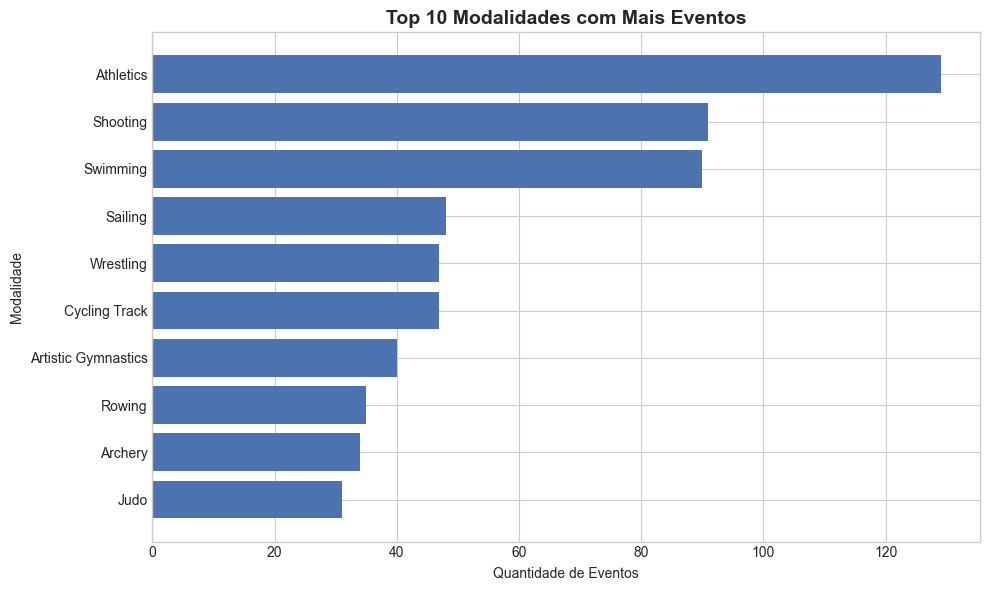

In [12]:
df_top10 = df_summary.head(10).copy()
df_top10 = df_top10.sort_values(by='num_events', ascending=True)

plt.figure(figsize=(10, 6))

plt.style.use('seaborn-v0_8-whitegrid')

plt.barh(df_top10['sport'], df_top10['num_events'], color='#4c72b0')

plt.title('Top 10 Modalidades com Mais Eventos', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Eventos')
plt.ylabel('Modalidade')

plt.tight_layout()

plt.savefig("../analise_modalidades/modalidades_top10.png", dpi=300)

plt.show()

6. **Reclassificação do tipo de edição**

Garante que a coluna 'tipo' está corretamente definida para cada edição olímpica.

In [13]:
df['tipo'] = df['edition'].apply(
    lambda x: 'Summer' if 'Summer' in x else 'Winter'
)

7. **Cálculo do número de modalidades por edição**

Agrupa os dados para obter o número de modalidades distintas em cada edição e tipo de olimpíada.

In [14]:
df_tipo = df.groupby(['edition', 'tipo'])['sport'].nunique().reset_index()

8. **Pivotagem dos dados**

Transforma o DataFrame para que cada linha represente uma edição e cada coluna um tipo de olimpíada, facilitando a análise temporal.

In [15]:
df_pivot = df_tipo.pivot(
    index='edition',
    columns='tipo',
    values='sport'
).fillna(0).reset_index()

9. **Cálculo do total de modalidades por edição**

Adiciona uma coluna com o total de modalidades (soma de verão e inverno) para cada edição olímpica.

In [16]:
df_pivot['Total'] = df_pivot.get('Summer', 0) + df_pivot.get('Winter', 0)

10. **Extração do ano e ordenação**

Extrai o ano da edição olímpica e ordena o DataFrame para análise temporal.

In [18]:
df_pivot['ano'] = df_pivot['edition'].str.extract(r'(\d{4})').astype(int)
df_pivot = df_pivot.sort_values(by='ano')

11. **Gráfico de evolução das modalidades olímpicas**

Gera um gráfico mostrando a evolução do número de modalidades olímpicas de verão e inverno ao longo dos anos, com suavização das curvas.

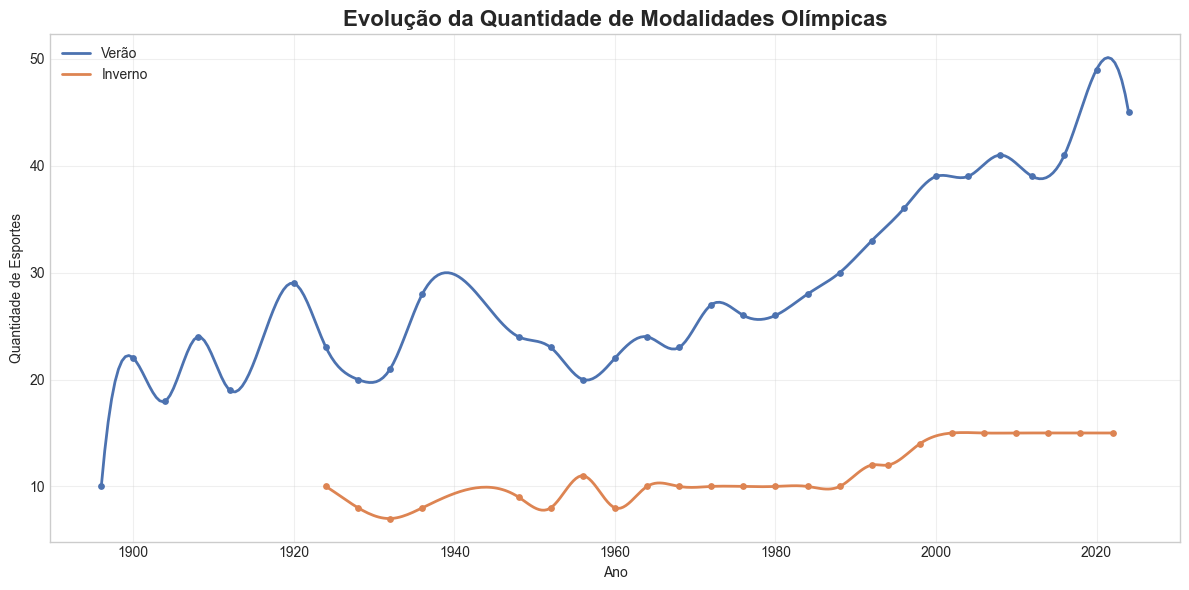

In [28]:
plt.style.use('seaborn-v0_8-whitegrid')

# Função robusta para suavizar, sem erro de duplicidade e com fallback para poucos pontos
import numpy as np
from scipy.interpolate import make_interp_spline
import pandas as pd

def suavizar(x, y):
    df_temp = pd.DataFrame({'x': x, 'y': y})
    # Remove duplicatas em x agregando pela média
    df_temp = df_temp.groupby('x', as_index=False).mean()
    x_uniq = df_temp['x'].values
    y_uniq = df_temp['y'].values
    # Se menos de 4 pontos, retorna linha reta
    if len(x_uniq) < 4:
        return x_uniq, y_uniq
    x_new = np.linspace(x_uniq.min(), x_uniq.max(), 300)
    spline = make_interp_spline(x_uniq, y_uniq, k=3)
    y_smooth = spline(x_new)
    return x_new, y_smooth

# Garantir anos únicos e soma por ano
if 'ano' in df_pivot.columns:
    df_pivot = df_pivot.groupby('ano', as_index=False).agg({
        'Summer': 'sum',
        'Winter': 'sum'
    })

plt.figure(figsize=(12, 6))
cor_verao = '#4c72b0'
cor_inverno = '#dd8452'

# --- Verão ---
df_verao = df_pivot[df_pivot['Summer'] > 0].copy()
if not df_verao.empty:
    x_s, y_s = suavizar(df_verao['ano'], df_verao['Summer'])
    plt.plot(x_s, y_s, color=cor_verao, linewidth=2, label='Verão')
    plt.scatter(df_verao['ano'], df_verao['Summer'], color=cor_verao, s=15)

# --- Inverno ---
df_inverno = df_pivot[df_pivot['Winter'] > 0].copy()
if not df_inverno.empty:
    x_w, y_w = suavizar(df_inverno['ano'], df_inverno['Winter'])
    plt.plot(x_w, y_w, color=cor_inverno, linewidth=2, label='Inverno')
    plt.scatter(df_inverno['ano'], df_inverno['Winter'], color=cor_inverno, s=15)

plt.title('Evolução da Quantidade de Modalidades Olímpicas', fontsize=16, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Esportes')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../analise_modalidades/modalidades_evolucao_suave.png", dpi=300)
plt.show()